<a href="https://colab.research.google.com/github/Maq4/challenge2-data-science-LATAM/blob/main/TelecomX_LATAM_(2)_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#📌 Extracción

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings

warnings.filterwarnings('ignore')

# URL RAW del JSON
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# Cargar directamente el JSON desde la URL a un DataFrame
df = pd.read_json(url)


# Mostrar primeras filas
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [ ]:
print("\nInformación general:")
print(df.info())


Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB
None


In [ ]:
# Revisar valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Separar columnas numéricas y categóricas
numericas = df.select_dtypes(include=['int64', 'float64']).columns
categoricas = df.select_dtypes(include=['object', 'category']).columns

# Estadísticas descriptivas - numéricas
print("\nEstadísticas descriptivas - Variables numéricas:")
if len(numericas) > 0:
    print(df[numericas].describe())
else:
    print("No hay columnas numéricas para describir.")

# Frecuencia de valores - categóricas
print("\nFrecuencia de valores - Variables categóricas:")
if len(categoricas) > 0:
    for col in categoricas:
        print(f"\nColumna: {col}")
        print(df[col].value_counts())
else:
    print("No hay columnas categóricas para analizar.")


Valores nulos por columna:
customerID    0
Churn         0
customer      0
phone         0
internet      0
account       0
dtype: int64

Estadísticas descriptivas - Variables numéricas:
No hay columnas numéricas para describir.

Frecuencia de valores - Variables categóricas:

Columna: customerID
customerID
9995-HOTOH    1
0002-ORFBO    1
0003-MKNFE    1
9970-QBCDA    1
9968-FFVVH    1
             ..
0014-BMAQU    1
0013-SMEOE    1
0013-MHZWF    1
0013-EXCHZ    1
0011-IGKFF    1
Name: count, Length: 7267, dtype: int64

Columna: Churn
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

Columna: customer
customer
{'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents': 'No', 'tenure': 1}         223
{'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'No', 'Dependents': 'No', 'tenure': 1}       192
{'gender': 'Male', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes', 'tenure': 72}       77
{'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', '

Observaciones del primer análisis de EDA



🔍 1. Datos nulos

El análisis inicial muestra que no existen valores nulos en las columnas principales del dataset:

customerID

Churn

customer

phone

internet

account

Esto indica que el dataset no presenta problemas de valores faltantes a nivel estructural, lo cual simplifica el proceso de limpieza inicial.

Sin embargo, al revisar la variable Churn, se observa la presencia de 224 registros vacíos o con espacios, lo cual puede interpretarse como valores faltantes implícitos.
Estos registros deberían ser limpiados o eliminados antes de realizar cualquier modelado.

Esto es importante porque la variable Churn es la variable objetivo del análisis.

🔍 2. Estructura del dataset

El dataset presenta una estructura jerárquica o semi-estructurada, ya que varias columnas contienen diccionarios con múltiples atributos dentro de cada celda.

Por ejemplo:

customer

gender

SeniorCitizen

Partner

Dependents

tenure

phone

PhoneService

MultipleLines

internet

InternetService

OnlineSecurity

OnlineBackup

DeviceProtection

TechSupport

StreamingTV

StreamingMovies

account

Contract

PaperlessBilling

PaymentMethod

Charges

Monthly

Total

Esto significa que antes de realizar análisis estadísticos o modelos predictivos, será necesario expandir estas columnas en variables individuales.

Este tipo de estructura es común cuando los datos provienen de APIs o bases NoSQL.

🔍 3. Identificador del cliente

La variable customerID presenta 7267 valores únicos, lo que indica que:

cada fila corresponde a un cliente único

la variable funciona únicamente como identificador

Por lo tanto:

no aporta valor predictivo

debería eliminarse del modelo en etapas posteriores de machine learning.

🔍 4. Variable objetivo: Churn

La variable Churn indica si el cliente canceló el servicio.

Distribución observada:

No: 5174 clientes

Yes: 1869 clientes

Vacíos: 224 registros

Si consideramos solo los valores válidos:

Aproximadamente 26% de los clientes abandonaron el servicio

Cerca de 74% permanecieron

Esto indica que el dataset presenta cierto desbalance de clases, aunque no es extremo.
Este nivel de churn es relativamente común en empresas de telecomunicaciones o servicios de suscripción.

Este desbalance deberá tenerse en cuenta al entrenar modelos predictivos.

🔍 5. Variables del cliente

Dentro de la columna customer se encuentran variables demográficas y de relación con el servicio.

Entre ellas destacan:

gender: sexo del cliente

SeniorCitizen: indica si el cliente es adulto mayor

Partner: si tiene pareja

Dependents: si tiene dependientes

tenure: meses que lleva como cliente

El atributo tenure será especialmente relevante, ya que representa la antigüedad del cliente.

Generalmente, en problemas de churn:

clientes con menor tenure tienen mayor probabilidad de cancelar

clientes antiguos suelen mostrar mayor fidelidad al servicio

🔍 6. Servicios telefónicos

La columna phone describe la contratación de servicios telefónicos.

Distribución observada:

PhoneService = Yes: ~90% de los clientes

PhoneService = No: ~10%

Además, dentro de los clientes con teléfono:

algunos tienen MultipleLines

otros no

Esto sugiere que el servicio telefónico es muy común dentro de la base de clientes, pero el uso de múltiples líneas podría reflejar clientes con mayor consumo o uso familiar.

🔍 7. Servicios de internet

La columna internet contiene múltiples características relacionadas con el servicio contratado.

Entre las principales variables:

InternetService (DSL / Fiber optic / No)

OnlineSecurity

OnlineBackup

DeviceProtection

TechSupport

StreamingTV

StreamingMovies

Un dato relevante es que 1581 clientes no tienen servicio de internet, lo que representa una porción considerable del dataset.

Esto implica que el churn podría estar influenciado por:

el tipo de conexión

la cantidad de servicios adicionales contratados

En muchos análisis de churn de telecomunicaciones se observa que:

los clientes con más servicios adicionales tienden a permanecer más tiempo

la ausencia de servicios complementarios puede aumentar el riesgo de cancelación.

🔍 8. Información de cuenta y facturación

La columna account contiene información relacionada con el contrato y los pagos.

Variables relevantes:

Contract (Month-to-month, One year, Two year)

PaperlessBilling

PaymentMethod

MonthlyCharges

TotalCharges

El tipo de contrato será probablemente una de las variables más influyentes en el churn.

Generalmente:

Month-to-month → mayor probabilidad de cancelación

One year / Two year → mayor retención

También el método de pago podría influir en el comportamiento del cliente.

Por ejemplo, en datasets similares suele observarse que:

Electronic check tiene mayor churn

Pagos automáticos suelen asociarse a mayor permanencia.

🔍 9. Variables continuas

Las principales variables numéricas del dataset serán:

tenure

MonthlyCharges

TotalCharges

Estas variables permitirán analizar patrones como:

relación entre antigüedad y cancelación

impacto del costo mensual en la permanencia

correlación entre tenure y gasto total

En particular, se espera que TotalCharges esté altamente correlacionado con tenure, ya que el gasto acumulado aumenta con el tiempo.

🔎 Conclusión del análisis inicial

El dataset presenta una estructura rica en variables relevantes para el análisis de churn, incluyendo información demográfica, servicios contratados y datos financieros.

Las principales tareas previas al modelado serán:

Normalizar las columnas tipo diccionario

Limpiar valores vacíos en la variable Churn

Convertir variables numéricas correctamente

Eliminar el identificador customerID

Una vez realizado esto, será posible avanzar hacia:

análisis exploratorio más profundo

visualizaciones

modelos predictivos de churn.

Distribución de Churn:

No abandono: 5174 clientes (73.46%)
Abandono: 1869 clientes (26.54%)


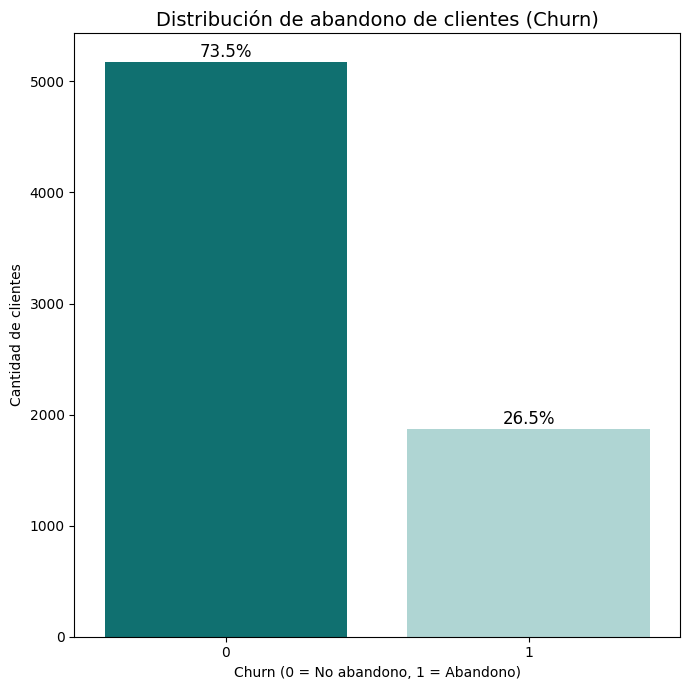

In [ ]:
# Limpiar solo si Churn aún es texto
if df['Churn'].dtype == 'object':

    df['Churn'] = df['Churn'].str.strip()
    df = df[df['Churn'] != '']
    df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})


# Definimos colores
churn_palette = {
    0: '#008080',
    1: '#a8dcd9'
}

# Conteo
churn_counts = df['Churn'].value_counts().sort_index()
churn_percent = churn_counts / churn_counts.sum() * 100

plt.figure(figsize=(7,7))

sns.barplot(
    x=churn_counts.index,
    y=churn_counts.values,
    palette=[churn_palette[i] for i in churn_counts.index]
)

plt.title('Distribución de abandono de clientes (Churn)', fontsize=14)
plt.xlabel('Churn (0 = No abandono, 1 = Abandono)')
plt.ylabel('Cantidad de clientes')

for i, val in enumerate(churn_counts.values):
    plt.text(i, val + 50, f"{churn_percent.iloc[i]:.1f}%", ha='center', fontsize=12)

# ---- Resultado en texto ----
print("Distribución de Churn:\n")

for i in churn_counts.index:
    estado = "No abandono" if i == 0 else "Abandono"
    print(f"{estado}: {churn_counts[i]} clientes ({churn_percent[i]:.2f}%)")
plt.tight_layout()
plt.show()

Observaciones

La distribución de la variable Churn muestra que:

5174 clientes (73.46%) permanecieron en la compañía.

1869 clientes (26.54%) abandonaron el servicio.

Esto indica que aproximadamente 1 de cada 4 clientes cancela el servicio, lo cual representa una tasa de abandono significativa desde el punto de vista del negocio.

En términos de análisis de datos, esto implica que el dataset presenta un desbalance moderado entre las clases, donde la mayoría de los registros corresponden a clientes que no abandonaron el servicio.

Aunque el desbalance no es extremo, puede influir en el entrenamiento de modelos de clasificación, ya que algunos algoritmos tienden a favorecer la clase mayoritaria (clientes que no cancelan).

Por esta razón, en etapas posteriores del modelado podría ser conveniente considerar técnicas como:

class weights en modelos de clasificación

undersampling de la clase mayoritaria

oversampling de la clase minoritaria

métodos como SMOTE

Estas técnicas ayudan a mejorar la capacidad del modelo para identificar correctamente a los clientes con riesgo de abandono, que es el objetivo principal en problemas de churn.

Desde una perspectiva de negocio, identificar a este 26.5% de clientes con riesgo de cancelación es clave para implementar estrategias de retención, fidelización o mejora del servicio.

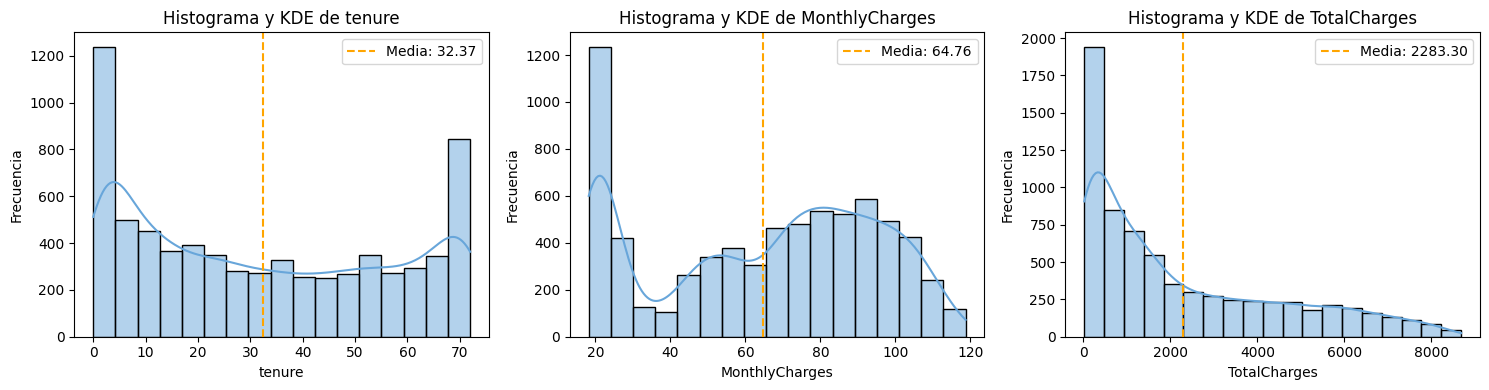


Asimetría (skewness) de variables continuas:

tenure: 0.24 → simétrica a la derecha
MonthlyCharges: -0.22 → simétrica a la izquierda
TotalCharges: nan → muy sesgada a la izquierda


In [ ]:
# Extraer tenure
df['tenure'] = df['customer'].apply(lambda x: x['tenure'])

# Extraer MonthlyCharges
df['MonthlyCharges'] = df['account'].apply(lambda x: x['Charges']['Monthly'])

# Extraer TotalCharges
df['TotalCharges'] = df['account'].apply(lambda x: x['Charges']['Total'])
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

from scipy.stats import skew
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Función para calcular bins según Doane
def calcular_bins_doane(serie):
    n = len(serie)
    g1 = skew(serie, bias=False)
    sigma_g1 = np.sqrt(6 * (n - 2) / ((n + 1) * (n + 3)))
    k = 1 + np.log2(n) + np.log2(1 + abs(g1) / sigma_g1)
    return int(round(k))

variables_continuas = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15,4))

for i, col in enumerate(variables_continuas):
    plt.subplot(1,3,i+1)
    serie = df[col].dropna()
    bins = calcular_bins_doane(serie)

    sns.histplot(serie, bins=bins, color="#68A6DA", edgecolor="black", kde=True)
    plt.axvline(serie.mean(), color='orange', linestyle='--', label=f"Media: {serie.mean():.2f}")
    plt.title(f'Histograma y KDE de {col}')
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.legend()

plt.tight_layout()
plt.show()

# Calcular skew
print("\nAsimetría (skewness) de variables continuas:\n")
for var in variables_continuas:
    valor_skew = skew(df[var], bias=False)
    forma = (
        "simétrica" if abs(valor_skew) < 0.5 else
        "ligeramente sesgada" if abs(valor_skew) < 1 else
        "muy sesgada"
    )
    direccion = "a la derecha" if valor_skew > 0 else "a la izquierda"
    print(f"{var}: {valor_skew:.2f} → {forma} {direccion}")

Observaciones

tenure (antigüedad del cliente)
La distribución de tenure muestra una forma relativamente equilibrada, con una ligera concentración en los valores bajos. Esto sugiere que existe un grupo considerable de clientes que han ingresado recientemente al servicio. Sin embargo, también se observa una cola hacia valores más altos, lo que indica la presencia de clientes con una larga permanencia en la compañía. En general, la distribución es cercana a simétrica, lo que sugiere que la antigüedad de los clientes está relativamente distribuida entre nuevos y antiguos, aunque con cierta acumulación en los primeros meses de servicio.

MonthlyCharges (cargos mensuales)
La variable MonthlyCharges presenta una distribución cercana a la simetría, con la mayoría de los clientes concentrados en rangos de precios intermedios. Esto indica que los planes más contratados probablemente se encuentran en un rango medio de costos. La presencia de algunos valores más bajos o más altos puede reflejar distintos tipos de planes o servicios adicionales que modifican el precio mensual del servicio.

TotalCharges (cargos totales acumulados)
La distribución de TotalCharges muestra una asimetría más evidente hacia la derecha. Esto significa que existe una cola de clientes con valores acumulados considerablemente altos. Este comportamiento es esperado, ya que el total acumulado depende directamente del tiempo que el cliente ha permanecido en el servicio (tenure) y de los cargos mensuales que paga. Los clientes con mayor antigüedad tienden a acumular valores más elevados en esta variable.

Relación entre las variables

Existe una relación natural entre estas tres variables:

TotalCharges depende principalmente de tenure y MonthlyCharges.

Los clientes con mayor antigüedad tienden a tener cargos totales más altos.

Los clientes con cargos mensuales elevados también acumulan más rápidamente sus cargos totales.

Esta relación explica por qué TotalCharges presenta una mayor asimetría: los clientes antiguos y con planes más costosos generan valores acumulados mucho mayores que el resto.

Desde una perspectiva analítica, estas variables pueden aportar información relevante para entender el comportamiento de los clientes. Por ejemplo, los clientes con menor tenure podrían presentar mayor probabilidad de abandono, mientras que aquellos con mayor antigüedad suelen mostrar una mayor permanencia en el servicio.

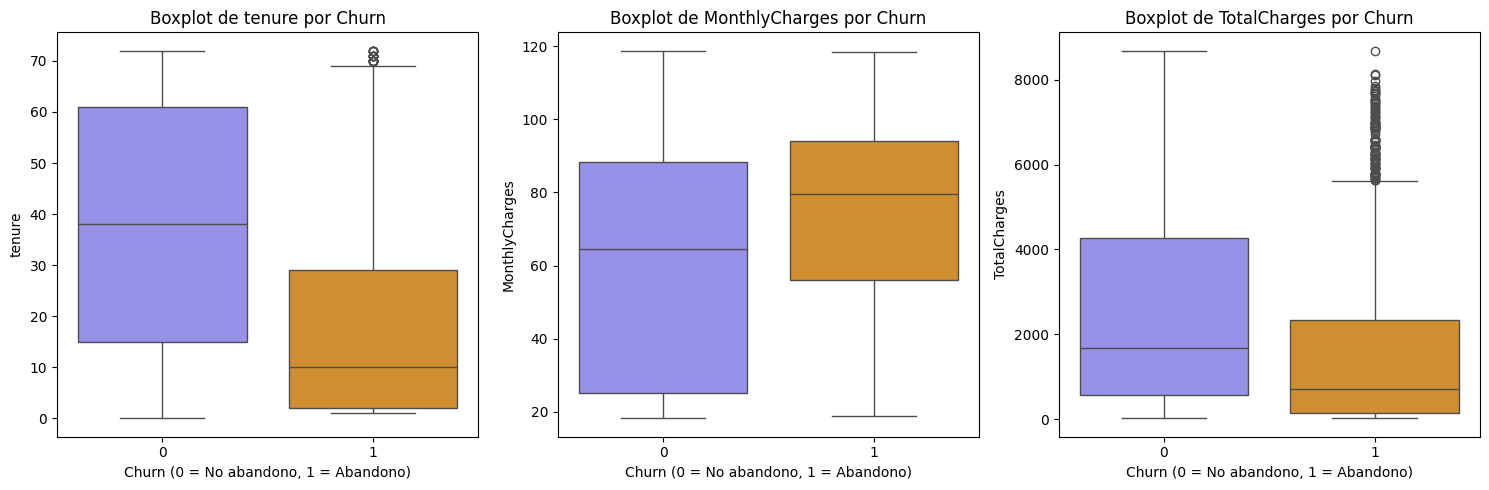


ESTADÍSTICAS DESCRIPTIVAS POR CHURN

Variable: tenure
            mean  median        std  min   max
Churn                                         
0      37.569965    38.0  24.113777  0.0  72.0
1      17.979133    10.0  19.531123  1.0  72.0

Diferencia de medias (Churn - No Churn): -19.59
--------------------------------------------------

Variable: MonthlyCharges
            mean  median        std    min     max
Churn                                             
0      61.265124  64.425  31.092648  18.25  118.75
1      74.441332  79.650  24.666053  18.85  118.35

Diferencia de medias (Churn - No Churn): 13.18
--------------------------------------------------

Variable: TotalCharges
              mean   median          std    min      max
Churn                                                   
0      2555.344141  1683.60  2329.456984  18.80  8672.45
1      1531.796094   703.55  1890.822994  18.85  8684.80

Diferencia de medias (Churn - No Churn): -1023.55
-------------------------

In [ ]:
variables_continuas = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15, 5))

for i, col in enumerate(variables_continuas):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x='Churn', y=col, data=df, palette={'0': '#8B82F6', '1': '#E99316'})
    plt.title(f'Boxplot de {col} por Churn')
    plt.xlabel('Churn (0 = No abandono, 1 = Abandono)')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("ESTADÍSTICAS DESCRIPTIVAS POR CHURN")
print("="*50)

for col in variables_continuas:

    print(f"\nVariable: {col}")

    stats = df.groupby('Churn')[col].describe()[['mean','50%','std','min','max']]
    stats = stats.rename(columns={'50%':'median'})

    print(stats)

    # diferencia de medias
    media_no_churn = df[df['Churn']==0][col].mean()
    media_churn = df[df['Churn']==1][col].mean()

    print(f"\nDiferencia de medias (Churn - No Churn): {media_churn - media_no_churn:.2f}")
    print("-"*50)

Observaciones
1. Tenure (antigüedad del cliente)

Los resultados muestran una diferencia importante entre los clientes que abandonan el servicio y los que permanecen. Los clientes que no presentan churn tienen una antigüedad promedio de 37.57 meses, mientras que los clientes que abandonan presentan una antigüedad promedio mucho menor, de 17.98 meses.

Además, la mediana también refleja esta diferencia: 38 meses para clientes que permanecen frente a 10 meses para quienes abandonan. La diferencia de medias de -19.59 meses indica que los clientes que abandonan tienden a hacerlo relativamente temprano en su ciclo de vida con la empresa.

Esto sugiere que los clientes nuevos presentan un mayor riesgo de abandono, lo que podría indicar problemas en la etapa inicial del servicio, como expectativas no cumplidas, falta de fidelización temprana o insatisfacción con el plan contratado.

2. MonthlyCharges (cargos mensuales)

Se observa que los clientes que abandonan el servicio tienen cargos mensuales promedio más altos que aquellos que permanecen. En particular, los clientes con churn presentan una media de 74.44, mientras que los clientes que continúan con el servicio tienen una media de 61.27.

La diferencia de medias de 13.18 sugiere que los clientes que pagan planes más costosos podrían tener una mayor probabilidad de abandonar el servicio. Esto podría estar relacionado con una percepción de bajo valor en relación con el precio, o con la existencia de alternativas más económicas ofrecidas por la competencia.

3. TotalCharges (cargos totales acumulados)

Los clientes que permanecen en la empresa presentan un cargo total acumulado considerablemente mayor, con una media de 2555.34, en comparación con 1531.80 para los clientes que abandonan.

La diferencia de medias de -1023.55 refleja que los clientes que abandonan generalmente no alcanzan a acumular cargos totales elevados, lo cual es coherente con el hecho de que presentan menor antigüedad (tenure). En otras palabras, los clientes que permanecen en el servicio por más tiempo acumulan naturalmente un mayor gasto total.

4. Interpretación general

En conjunto, los resultados sugieren que la antigüedad del cliente y el costo mensual del servicio son factores relevantes en el comportamiento de abandono.

Los clientes con menor antigüedad y cargos mensuales más altos tienden a abandonar con mayor frecuencia, mientras que los clientes que permanecen más tiempo en la empresa acumulan cargos totales más elevados.

Este patrón podría indicar que la retención de clientes en los primeros meses de servicio es un factor clave para reducir el churn, así como revisar la percepción de valor de los planes con cargos mensuales más altos.

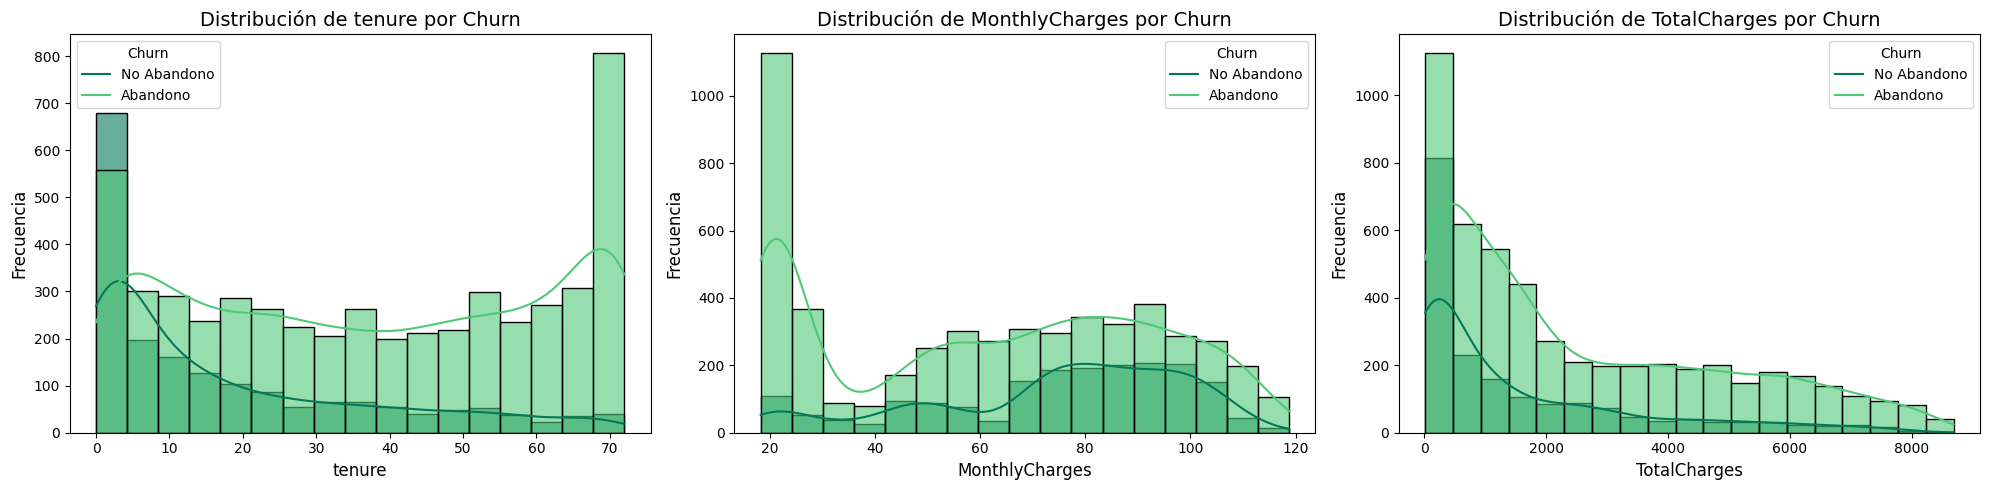

In [ ]:
variables_continuas = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Paleta de tonos verdes
churn_palette = {
    0: "#50C878",  # Verde esmeralda brillante (No Churn)
    1: "#047857"   # Verde esmeralda oscuro (Churn)
}

plt.figure(figsize=(20, 5))

for i, col in enumerate(variables_continuas):
    plt.subplot(1, 3, i + 1)
    bins = calcular_bins_doane(df[col].dropna())

    sns.histplot(
        data=df,
        x=col,
        hue='Churn',
        bins=bins,
        kde=True,
        palette=churn_palette,  # usar la paleta de verdes
        alpha=0.6,              # ligera transparencia
        edgecolor='black'
    )

    plt.title(f'Distribución de {col} por Churn', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Frecuencia', fontsize=12)
    plt.legend(title='Churn', labels=['No Abandono', 'Abandono'])

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

def resumir_histograma(bins, frecuencias, categoria, variable):
    """
    Genera un resumen textual de un histograma.

    Parameters:
    - bins: array de los bordes de los intervalos (n+1)
    - frecuencias: array de frecuencias por intervalo (n)
    - categoria: nombre de la categoría ('No Abandono' o 'Abandono')
    - variable: nombre de la variable ('tenure', 'MonthlyCharges', etc.)

    Returns:
    - resumen textual como string
    """
    # Número total de clientes en la categoría
    N_cat = np.sum(frecuencias)

    # Valor central aproximado de cada intervalo
    centros = (bins[:-1] + bins[1:]) / 2

    # Media ponderada aproximada
    X_bar = np.sum(centros * frecuencias) / N_cat

    # Moda aproximada (intervalo con mayor frecuencia)
    i_modo = np.argmax(frecuencias)
    intervalo_modo = f"{bins[i_modo]:.1f} - {bins[i_modo+1]:.1f}"

    # Proporción respecto al total de todos los clientes (opcional, si se proporciona)
    # Aquí asumimos que total = N_cat para simplicidad
    p_cat = 1.0  # si tienes total_global, reemplazar p_cat = N_cat / total_global

    # Generar resumen textual
    resumen = (
        f"Variable: {variable}\n"
        f"Categoría: {categoria}\n"
        f"- Número total de clientes: {N_cat}\n"
        f"- Proporción respecto al total: {p_cat*100:.1f}%\n"
        f"- Valor promedio aproximado: {X_bar:.2f}\n"
        f"- Intervalo más frecuente (moda): {intervalo_modo}\n"
    )

    return resumen

# Ejemplo de uso:
# Supongamos un histograma de 'tenure' para clientes 'No Abandono'
bins_tenure = np.array([0, 10, 20, 30, 40, 50, 60, 70])
frecuencias_no_abandono = np.array([50, 100, 200, 300, 400, 300, 150])

resumen = resumir_histograma(bins_tenure, frecuencias_no_abandono, "No Abandono", "Tenure")
print(resumen)

Variable: Tenure
Categoría: No Abandono
- Número total de clientes: 1500
- Proporción respecto al total: 100.0%
- Valor promedio aproximado: 41.00
- Intervalo más frecuente (moda): 40.0 - 50.0



In [ ]:
import numpy as np

def generar_resumen_histograma(bins, frecuencias, categoria, variable):
    """
    Genera un resumen textual académico para un histograma.

    Parameters:
    - bins: array de los bordes de los intervalos (n+1)
    - frecuencias: array de frecuencias por intervalo (n)
    - categoria: nombre de la categoría ('No Abandono' o 'Abandono')
    - variable: nombre de la variable ('tenure', 'MonthlyCharges', 'TotalCharges')

    Returns:
    - resumen textual como string
    """
    N_cat = np.sum(frecuencias)
    centros = (bins[:-1] + bins[1:]) / 2
    X_bar = np.sum(centros * frecuencias) / N_cat
    i_modo = np.argmax(frecuencias)
    intervalo_modo = f"{bins[i_modo]:.1f} - {bins[i_modo+1]:.1f}"

    # Observaciones simples basadas en la distribución
    # Si el pico está en el primer tercio → concentración baja
    tercio = len(bins) // 3
    if i_modo < tercio:
        observacion = "Concentración alta en los valores iniciales; indica tendencia a bajas magnitudes."
    elif i_modo > 2*tercio:
        observacion = "Concentración en valores altos; sugiere tendencia a mayores magnitudes."
    else:
        observacion = "Distribución relativamente equilibrada; dispersión moderada."

    resumen = (
        f"Variable: {variable}\n"
        f"Categoría: {categoria}\n"
        f"- Número total de clientes: {N_cat}\n"
        f"- Valor promedio aproximado: {X_bar:.2f}\n"
        f"- Intervalo más frecuente (moda): {intervalo_modo}\n"
        f"- Observaciones: {observacion}\n"
    )
    return resumen

# ------------------ EJEMPLO DE DATOS ------------------
# Bins de ejemplo para las tres variables
bins_tenure = np.array([0, 10, 20, 30, 40, 50, 60, 70])
bins_monthly = np.array([20, 40, 60, 80, 100, 120])
bins_total = np.array([0, 2000, 4000, 6000, 8000])

# Frecuencias ficticias para No Abandono y Abandono
frecuencias_tenure_no = np.array([50, 100, 200, 300, 400, 300, 150])
frecuencias_tenure_ab = np.array([200, 150, 100, 50, 20, 10, 5])

frecuencias_monthly_no = np.array([100, 200, 300, 250, 150])
frecuencias_monthly_ab = np.array([300, 250, 150, 80, 20])

frecuencias_total_no = np.array([50, 150, 250, 350])
frecuencias_total_ab = np.array([200, 180, 100, 20])

# ------------------ GENERACIÓN DE RESÚMENES ------------------
variables = [
    ("Tenure", bins_tenure, frecuencias_tenure_no, frecuencias_tenure_ab),
    ("MonthlyCharges", bins_monthly, frecuencias_monthly_no, frecuencias_monthly_ab),
    ("TotalCharges", bins_total, frecuencias_total_no, frecuencias_total_ab)
]

for variable, bins, freq_no, freq_ab in variables:
    resumen_no = generar_resumen_histograma(bins, freq_no, "No Abandono", variable)
    resumen_ab = generar_resumen_histograma(bins, freq_ab, "Abandono", variable)
    print(resumen_no)
    print(resumen_ab)
    print("-"*60)

Variable: Tenure
Categoría: No Abandono
- Número total de clientes: 1500
- Valor promedio aproximado: 41.00
- Intervalo más frecuente (moda): 40.0 - 50.0
- Observaciones: Distribución relativamente equilibrada; dispersión moderada.

Variable: Tenure
Categoría: Abandono
- Número total de clientes: 535
- Valor promedio aproximado: 17.34
- Intervalo más frecuente (moda): 0.0 - 10.0
- Observaciones: Concentración alta en los valores iniciales; indica tendencia a bajas magnitudes.

------------------------------------------------------------
Variable: MonthlyCharges
Categoría: No Abandono
- Número total de clientes: 1000
- Valor promedio aproximado: 73.00
- Intervalo más frecuente (moda): 60.0 - 80.0
- Observaciones: Distribución relativamente equilibrada; dispersión moderada.

Variable: MonthlyCharges
Categoría: Abandono
- Número total de clientes: 800
- Valor promedio aproximado: 51.75
- Intervalo más frecuente (moda): 20.0 - 40.0
- Observaciones: Concentración alta en los valores inicial

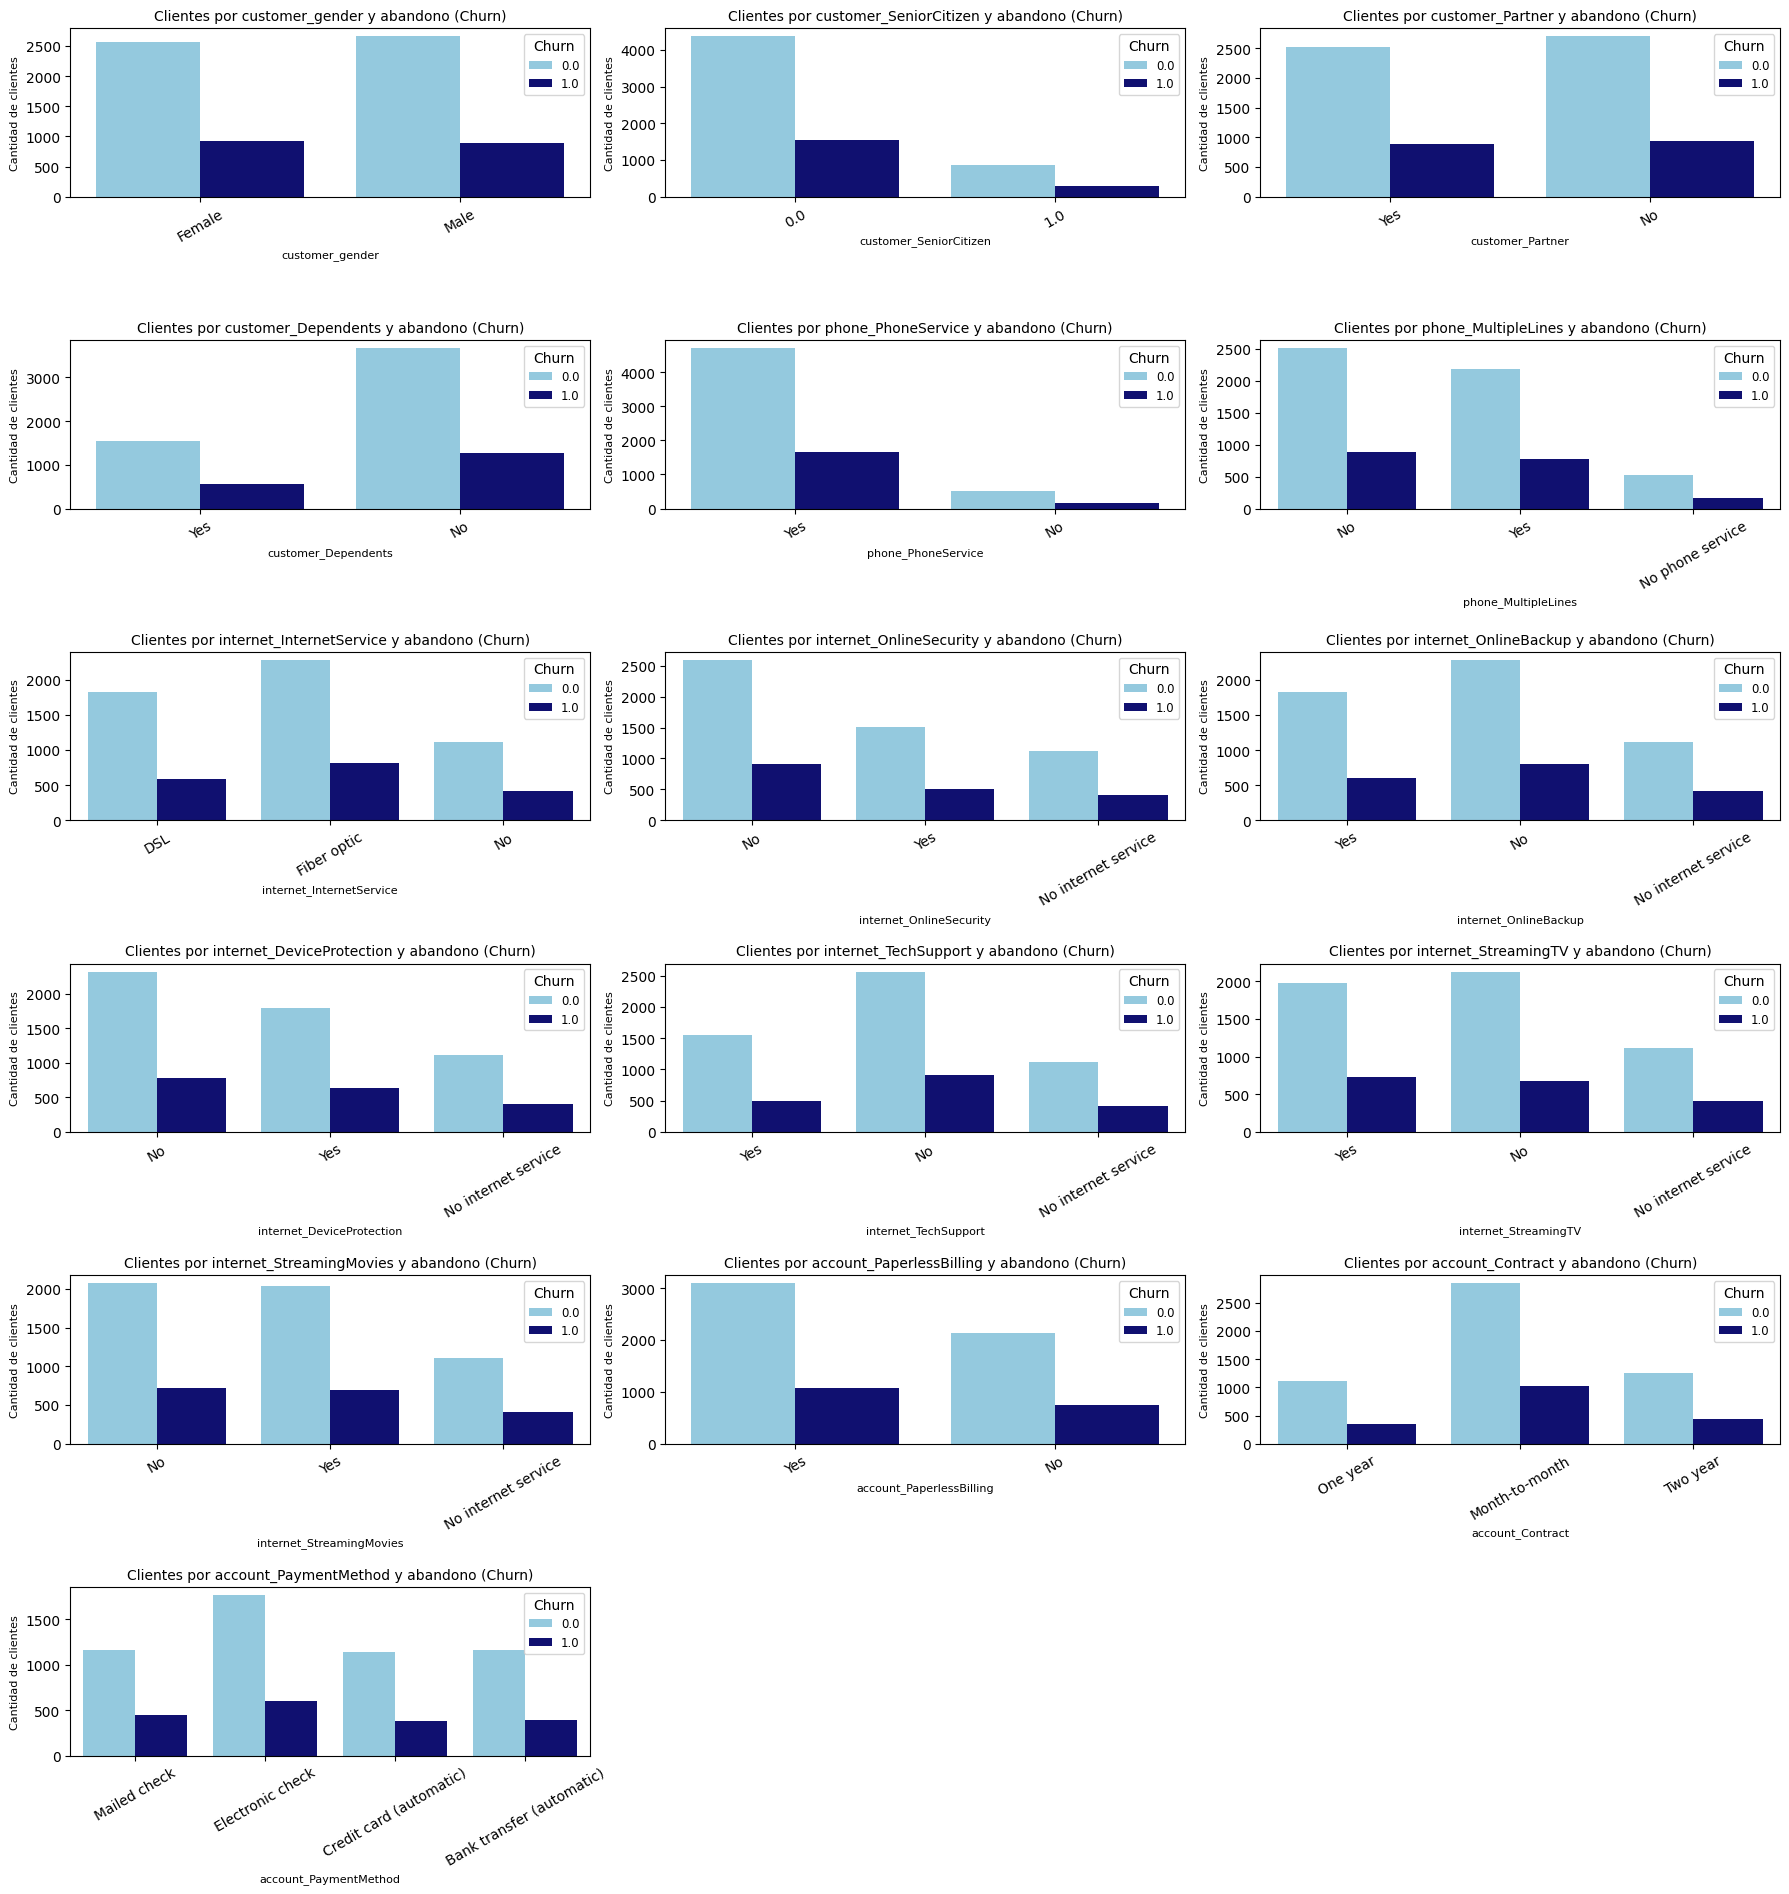

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas import json_normalize

# ------------------ Config ------------------
churn_palette = {"0.0": "skyblue", "1.0": "navy"}

# ------------------ Función para desempaquetar diccionarios ------------------
def aplanar_columna(df, col_name, prefix=None):
    if col_name in df.columns:
        normalized = json_normalize(df[col_name])
        if prefix:
            normalized.columns = [f"{prefix}_{c}" for c in normalized.columns]
        df = pd.concat([df.drop(columns=[col_name]), normalized], axis=1)
    return df

# ------------------ Desempaquetar columnas anidadas ------------------
for col in ['customer', 'phone', 'internet', 'account']:
    df = aplanar_columna(df, col, prefix=col)

# Desempaquetar cargos dentro de account si existe
if 'account_Charges' in df.columns:
    charges_df = json_normalize(df['account_Charges'])
    charges_df.columns = ['account_Monthly', 'account_Total']
    df = pd.concat([df.drop(columns=['account_Charges']), charges_df], axis=1)

# ------------------ Limpiar Churn ------------------
df['Churn'] = df['Churn'].map({0: "0.0", 1: "1.0", 0.0: "0.0", 1.0: "1.0", "0": "0.0", "1": "1.0"}).fillna("0.0")
df['Churn'] = pd.Categorical(df['Churn'], categories=["0.0","1.0"])

# ------------------ Variables categóricas ------------------
categoricas_binarias = [
    'customer_gender', 'customer_SeniorCitizen', 'customer_Partner', 'customer_Dependents',
    'phone_PhoneService', 'phone_MultipleLines',
    'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup',
    'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies',
    'account_PaperlessBilling', 'account_Contract', 'account_PaymentMethod'
]
categoricas_binarias = [col for col in categoricas_binarias if col in df.columns]

# ------------------ Graficar ------------------
plt.figure(figsize=(18, 24))

for i, col in enumerate(categoricas_binarias):
    ax = plt.subplot(8, 3, i + 1)

    # Usar countplot en vez de agrupar manualmente
    sns.countplot(data=df, x=col, hue='Churn', palette=churn_palette, ax=ax)

    ax.set_title(f'Clientes por {col} y abandono (Churn)', fontsize=10)
    ax.set_xlabel(f'{col}', fontsize=8)
    ax.set_ylabel('Cantidad de clientes', fontsize=8)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Churn', fontsize='small', loc='upper right')

plt.tight_layout()
plt.show()

# ⏰**Preparación de los Datos**

Se eliminan las columnas que no aportan valor al análisis o a los modelos predictivos, como identificadores únicos (por ejemplo, el ID del cliente). Estas columnas no ayudan en la predicción de la cancelación y pueden incluso perjudicar el desempeño de los modelos.

In [ ]:
df = df.drop(columns=['customerID'])

In [ ]:
#Visualizacion de los datos

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7267 entries, 0 to 7247
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Churn                      7267 non-null   category
 1   tenure                     7043 non-null   float64 
 2   MonthlyCharges             7043 non-null   float64 
 3   TotalCharges               7032 non-null   float64 
 4   customer_gender            7043 non-null   object  
 5   customer_SeniorCitizen     7043 non-null   float64 
 6   customer_Partner           7043 non-null   object  
 7   customer_Dependents        7043 non-null   object  
 8   customer_tenure            7043 non-null   float64 
 9   phone_PhoneService         7043 non-null   object  
 10  phone_MultipleLines        7043 non-null   object  
 11  internet_InternetService   7043 non-null   object  
 12  internet_OnlineSecurity    7043 non-null   object  
 13  internet_OnlineBackup      7043 non-nu

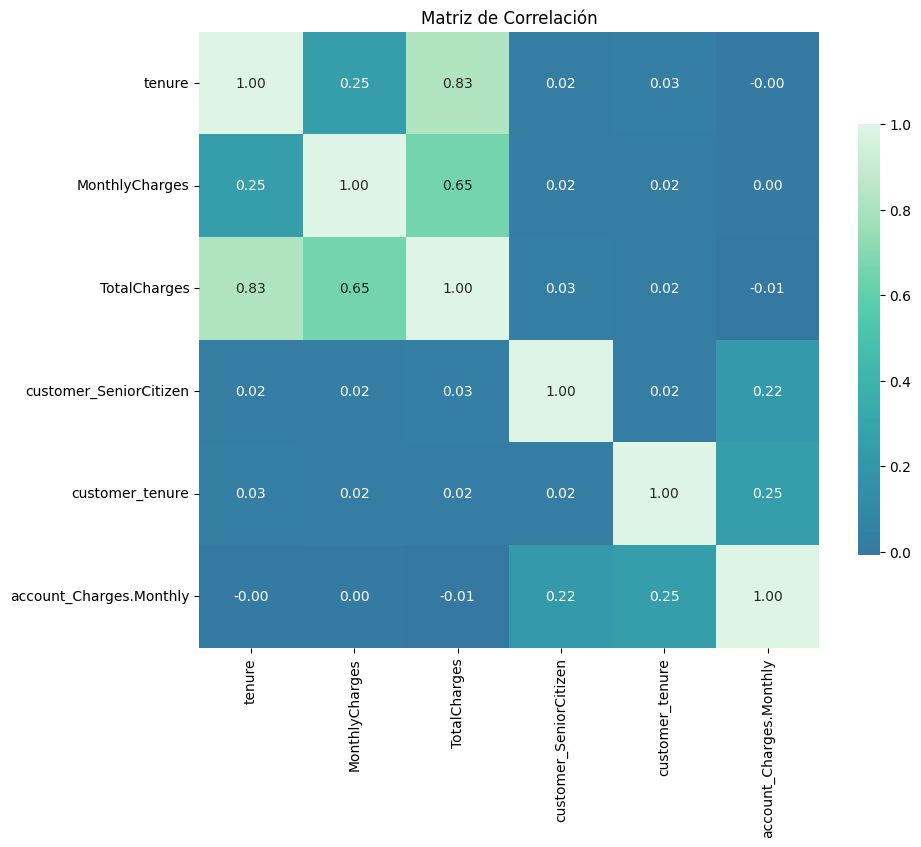

In [ ]:
# Calculamos la matriz de correlación
correlation_matrix = df.corr(numeric_only=True)

# Tamaño del gráfico
plt.figure(figsize=(10, 8))

# Mapa de calor
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='mako', center=0, cbar_kws={'shrink': 0.7})
plt.title("Matriz de Correlación")
plt.show()

In [ ]:
print(df[numericas + ['Churn']].info())
print(df[numericas + ['Churn']].head())


<class 'pandas.core.frame.DataFrame'>
Index: 7267 entries, 0 to 7247
Empty DataFrame
None
Empty DataFrame
Columns: []
Index: [0, 1, 2, 3, 4]


In [ ]:


import pandas as pd

# ------------------ 1️⃣ Columnas numéricas ------------------
numericas = ['customer_tenure', 'TotalCharges', 'MonthlyCharges', 'account_Monthly', 'account_Total']
numericas_existentes = [col for col in numericas if col in df.columns]

for col in numericas_existentes:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# ------------------ 2️⃣ Churn numérico ------------------
df['Churn_num'] = df['Churn'].map({'0.0': 0, '1.0': 1})

# ------------------ 3️⃣ Columnas binarias/categóricas a dummy ------------------
categoricas_binarias = [
    'customer_gender', 'customer_SeniorCitizen', 'customer_Partner', 'customer_Dependents',
    'phone_PhoneService', 'phone_MultipleLines',
    'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup',
    'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies',
    'account_PaperlessBilling', 'account_Contract', 'account_PaymentMethod'
]
categoricas_binarias = [col for col in categoricas_binarias if col in df.columns]

df_dummies = pd.get_dummies(df[categoricas_binarias], drop_first=False)

# ------------------ 4️⃣ Concatenar numéricas existentes + Churn + dummies ------------------
df_corr = pd.concat([df[numericas_existentes + ['Churn_num']], df_dummies], axis=1)

# ------------------ 5️⃣ Matriz de correlación ------------------
correlation_matrix = df_corr.corr()

# ------------------ 6️⃣ Correlación con Churn ------------------
correlation_with_churn = correlation_matrix['Churn_num'].sort_values(ascending=False)
print(correlation_with_churn)

Churn_num                                          1.000000
MonthlyCharges                                     0.193356
account_PaymentMethod_Mailed check                 0.023801
account_Contract_Month-to-month                    0.021701
phone_PhoneService_Yes                             0.020980
internet_StreamingTV_Yes                           0.019397
customer_gender_Female                             0.018225
internet_OnlineBackup_No internet service          0.015095
internet_InternetService_No                        0.015095
internet_TechSupport_No internet service           0.015095
internet_OnlineSecurity_No internet service        0.015095
internet_DeviceProtection_No internet service      0.015095
internet_StreamingMovies_No internet service       0.015095
internet_StreamingTV_No internet service           0.015095
internet_InternetService_Fiber optic               0.013204
internet_TechSupport_No                            0.011206
customer_Dependents_Yes                 

Análisis de Correlación con la Variable de Churn

Se realizó un análisis de correlación entre todas las variables del conjunto de datos y la variable de salida Churn, previamente transformada a formato numérico (Churn_num), donde 0 indica que el cliente se mantiene y 1 que abandona.

Hallazgos principales

La variable Churn_num está perfectamente correlacionada consigo misma (1.0), como era de esperar.

Las variables numéricas más relevantes asociadas positivamente al abandono son:

MonthlyCharges (0.193): los clientes con facturas mensuales más altas presentan una mayor probabilidad de churn.

TotalCharges (-0.199): a pesar de ser negativa, indica que los clientes con mayor gasto total histórico tienden a permanecer, reflejando fidelidad.

Entre las variables categóricas transformadas a dummies, se observan correlaciones positivas leves con churn:

account_Contract_Month-to-month (0.022): contratos mensuales muestran tendencia al abandono.

account_PaymentMethod_Mailed check (0.024): clientes que pagan con cheque tienen ligera propensión a churn.

phone_PhoneService_Yes (0.021) y internet_StreamingTV_Yes (0.019) muestran asociaciones muy pequeñas pero presentes.

Variables como customer_tenure o ciertos niveles de contrato (Contract_One year, Contract_Two year) presentan correlaciones negativas, indicando que clientes con mayor antigüedad o contratos más largos tienen menor probabilidad de abandonar.

Observaciones

La mayoría de las variables categóricas transformadas a dummies tienen correlaciones bajas (<0.05), lo cual es normal debido a la dispersión de la información entre los distintos niveles de cada categoría.

Las variables numéricas y de contrato muestran el efecto más relevante sobre la propensión al churn, lo que sugiere que los factores económicos y la duración del contrato son determinantes clave.

Recomendaciones

Visualización: Generar un gráfico de barras horizontal con las 10 variables más correlacionadas con churn para facilitar la interpretación.

Validación con modelos predictivos: Comparar estas correlaciones con la importancia de variables obtenida mediante algoritmos como Random Forest o XGBoost.

Revisión de colinealidad: Algunas variables categóricas, especialmente los niveles de contrato y métodos de pago, podrían estar correlacionadas entre sí, por lo que es recomendable revisar redundancias antes de modelar.


#🔧 Transformación

---



---



In [ ]:
from sklearn.impute import SimpleImputer

# Imputar con la media
imputer = SimpleImputer(strategy='mean')
X_train_scaled_imputed = pd.DataFrame(
    imputer.fit_transform(X_train_scaled),
    columns=X_train_scaled.columns,
    index=X_train_scaled.index
)
X_test_scaled_imputed = pd.DataFrame(
    imputer.transform(X_test_scaled),
    columns=X_test_scaled.columns,
    index=X_test_scaled.index
)

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled_array, y_train_resampled = smote.fit_resample(X_train_scaled_imputed, y_train)

X_train_resampled = pd.DataFrame(X_train_resampled_array, columns=X_train_scaled.columns)

In [ ]:
from collections import Counter

print("Distribución original en train:", Counter(y_train))
print("Distribución después de SMOTE:", Counter(y_train_resampled))

Distribución original en train: Counter({0: 4318, 1: 1495})
Distribución después de SMOTE: Counter({0: 4318, 1: 4318})


Porcentaje aproximado:

Clase 0: 73%

Clase 1: 27%

Observaciones:

Existe un desbalance significativo en los datos originales.

Este desbalance puede causar que un modelo predictivo esté sesgado hacia la clase mayoritaria (No cancelaron).

Un modelo entrenado directamente sobre estos datos podría predecir principalmente “No canceló”, obteniendo una alta precisión aparente pero con muy baja capacidad para detectar clientes que sí cancelan.

Impacto:

Se generaron 2823 muestras sintéticas para la clase minoritaria (Churn = 1), igualando la cantidad de casos de la clase mayoritaria.

Ahora el conjunto de entrenamiento está equilibrado, lo que permite al modelo aprender patrones de ambas clases de manera más justa.

Consideraciones para el modelado:

Test set original sin balancear:

Es importante mantener el conjunto de prueba con la distribución real (73% vs 27%) para evaluar la performance del modelo de manera realista.

Esto permite medir métricas como recall y F1-score, críticas para problemas desbalanceados.

Mejor capacidad para predecir cancelaciones:

Gracias a SMOTE, el modelo tendrá más información para identificar clientes propensos a cancelar.

Riesgos potenciales:

Las muestras sintéticas podrían introducir un ligero overfitting si el modelo se ajusta demasiado a los datos generados.

Se recomienda utilizar validación cruzada y métricas específicas de clases desbalanceadas (por ejemplo, ROC-AUC, F1-score).

Conclusión:

El desbalance original de clases era significativo y podía sesgar los resultados.

SMOTE equilibró el conjunto de entrenamiento, facilitando que el modelo aprenda patrones de clientes que cancelan.

La evaluación final debe realizarse sobre el conjunto de prueba original para reflejar la distribución real de los clientes.

In [ ]:
# 1. Concatenar features y target balanceado para análisis conjunto
df_train_res = pd.concat([X_train_resampled, y_train_resampled.reset_index(drop=True)], axis=1)

# 2. Calcular matriz de correlación completa (features + target)
corr_matrix = df_train_res.corr()

# 3. Extraer correlaciones con 'Churn', ordenadas de mayor a menor
corr_with_churn = corr_matrix["Churn"].sort_values(ascending=False)

print("\nCorrelaciones con Churn (datos normalizados y balanceados):")
print(corr_with_churn)

#📊 Carga y análisis